<!DOCTYPE html>
<html lang="en">


<body>


    
    
</div> 


<body>


    
</html>

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="stylesheet" href="https://use.typekit.net/your-typekit-id.css">
</head>
<body>
    
    
<div style="background-color: #000000; color: white; text-align: center; padding: 10px; font-family: 'Proxima Nova', sans-serif; font-size: 24px;">
    Replication Lab  <br>
    GEC0319 | Time Series <br>
    
    
</div>



    
    
</body>
</html>

This notebook resumes a series of items:

- [X] Pearson's correlation performance under noise and non-linear relationships compared to alternative measures:

- [X] Mutual Informations

- [X] Xi Correlation

#### Design

>*Synthetic data to test the limits of Pearson Correlation.*

https://towardsdatascience.com/a-new-coefficient-of-correlation-64ae4f260310

https://medium.com/latinxinai/computing-mutual-information-matrix-with-python-6ced9169bcb1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import pandas as po

import warnings
warnings.simplefilter(action='ignore', category= FutureWarning)

# general settings
class CFG:
    data_folder = '../input/tsdata-1/'
    img_dim1 = 20
    img_dim2 = 10
    style = style = 'https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle'


    
# adjust the parameters for displayed figures    
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})    

plt.style.use(CFG.style)

In [12]:
## Python Function ##
from numpy import array, random, arange

def xicor(X, Y, ties=True):
    random.seed(42)
    n = len(X)
    order = array([i[0] for i in sorted(enumerate(X), key=lambda x: x[1])])
    if ties:
        l = array([sum(y >= Y[order]) for y in Y[order]])
        r = l.copy()
        for j in range(n):
            if sum([r[j] == r[i] for i in range(n)]) > 1:
                tie_index = array([r[j] == r[i] for i in range(n)])
                r[tie_index] = random.choice(r[tie_index] - arange(0, sum([r[j] == r[i] for i in range(n)])), sum(tie_index), replace=False)
        return 1 - n*sum( abs(r[1:] - r[:n-1]) ) / (2*sum(l*(n - l)))
    else:
        r = array([sum(y >= Y[order]) for y in Y[order]])
        return 1 - 3 * sum( abs(r[1:] - r[:n-1]) ) / (n**2 - 1)

def xicor_matrix(data, ties=True):
    n_vars = len(data)
    correlation_matrix = np.zeros((n_vars, n_vars))
    
    for i in range(n_vars):
        for j in range(i, n_vars):
            correlation_matrix[i, j] = xicor(data[i], data[j], ties=ties)
            correlation_matrix[j, i] = xicor(data[j], data[i], ties=ties) # correlation_matrix[i, j]  # Since it's symmetric
    
    return correlation_matrix

In [13]:
def joint_entropies(data, nbins=None):
    n_variables = data.shape[-1]
    n_samples = data.shape[0]
    if nbins == None:
        nbins = int((n_samples/5)**.5)
    histograms2d = np.zeros((n_variables, n_variables, nbins, nbins))
    for i in range(n_variables):
        for j in range(n_variables):
            histograms2d[i,j] = np.histogram2d(data[:,i], data[:,j], bins=nbins)[0]
    probs = histograms2d / len(data) + 1e-100
    joint_entropies = -(probs * np.log2(probs)).sum((2,3))
    return joint_entropies

def mutual_info_matrix(df, nbins=None, normalized=True):
    data = df.to_numpy()
    n_variables = data.shape[-1]
    j_entropies = joint_entropies(data, nbins)
    entropies = j_entropies.diagonal()
    entropies_tile = np.tile(entropies, (n_variables, 1))
    sum_entropies = entropies_tile + entropies_tile.T
    mi_matrix = sum_entropies - j_entropies
    if normalized:
        mi_matrix = mi_matrix * 2 / sum_entropies    
    return pd.DataFrame(mi_matrix, index=df.columns, columns=df.columns)

## **Pearson Correlation, Xi Correlation and Mutual Information** 
- Experiment N° **0**  
- Link: [here](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)

In [5]:
y_simple

NameError: name 'y_simple' is not defined

In [14]:
x_simple = np.array([-2, -1, 0, 1, 2])
y_simple = np.array([4, 1, 3, 2, 0])
my_rho = np.corrcoef(x_simple, y_simple)

print(my_rho)

[[ 1.  -0.7]
 [-0.7  1. ]]


In [15]:
xicor = xicor(x_simple, y_simple)
xicor

0.0

In [16]:
seed = 13
rand = np.random.RandomState(seed)

x = rand.uniform(0,1,100)
x = np.vstack((x,x*2+1))
x = np.vstack((x,-x[0,]*2+1))
x = np.vstack((x,rand.normal(1,3,100)))

In [17]:
pd.DataFrame(xicor_matrix(x)).round(1)

NameError: name 'pd' is not defined

In [225]:
# plt.plot(x[1])

### An example

In [4]:
rho = np.corrcoef(x)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
for i in [0,1,2]:
    ax[i].scatter(x[0,],x[1+i,])
    ax[i].title.set_text('Correlation = ' + "{:.2f}".format(rho[0,i+1]))
    ax[i].set(xlabel='x',ylabel='y')
fig.subplots_adjust(wspace=.4)    
plt.show()

NameError: name 'x' is not defined

### Noise

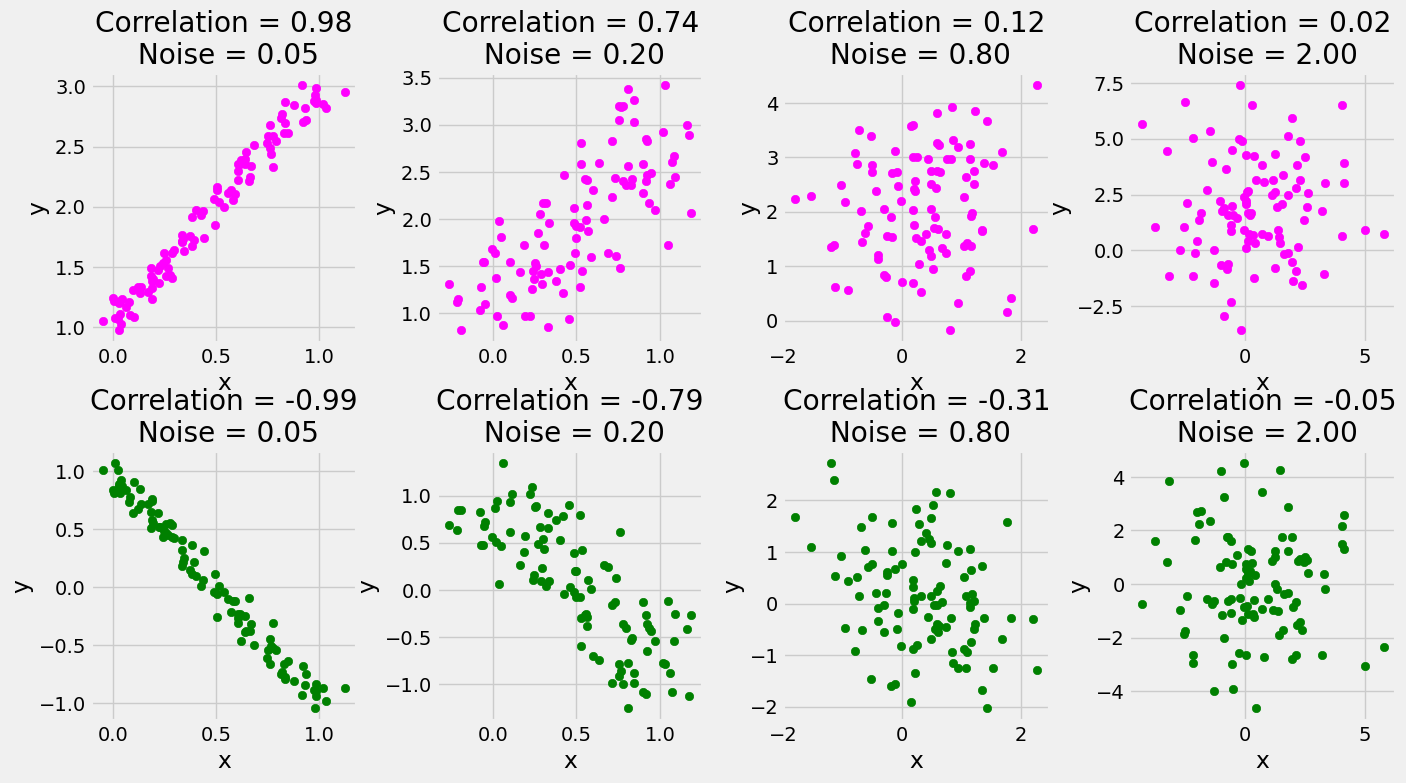

In [277]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))

for noise, i in zip([0.05,0.2,0.8,2],[0,1,2,3]):
    # Add noise
    x_with_noise = x+rand.normal(0,noise,x.shape)
    
    # Compute correlation
    rho_noise = np.corrcoef(x_with_noise)
    
    # Plot column wise. Positive correlation in row 0 and negative in row 1
    ax[0,i].scatter(x_with_noise[0,],x_with_noise[1,],color='magenta')
    ax[1,i].scatter(x_with_noise[0,],x_with_noise[2,],color='green')
    ax[0,i].title.set_text('Correlation = ' + "{:.2f}".format(rho_noise[0,1])
                        + '\n Noise = ' + "{:.2f}".format(noise) )
    ax[1,i].title.set_text('Correlation = ' + "{:.2f}".format(rho_noise[0,2])
                        + '\n Noise = ' + "{:.2f}".format(noise))
    ax[0,i].set(xlabel='x',ylabel='y')    
    ax[1,i].set(xlabel='x',ylabel='y')
    
fig.subplots_adjust(wspace=0.3,hspace=0.4)    
plt.show()

### Non Linear Relations

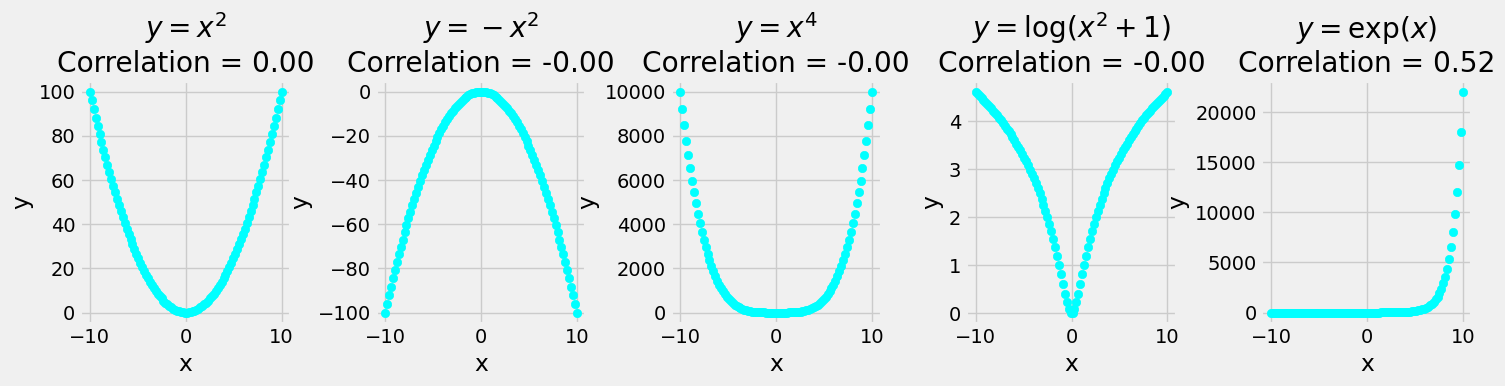

In [82]:
# Create a data matrix
x_nonlinear = np.linspace(-10,10,100)
x_nonlinear = np.vstack((x_nonlinear,x_nonlinear*x_nonlinear))
x_nonlinear = np.vstack((x_nonlinear,-x_nonlinear[0,]**2))
x_nonlinear = np.vstack((x_nonlinear,x_nonlinear[0,]**4))
x_nonlinear = np.vstack((x_nonlinear,np.log(x_nonlinear[0,]**2+1)))
x_nonlinear = np.vstack((x_nonlinear,np.exp(x_nonlinear[0,])))

# Compute the correlation
rho_nonlinear = np.corrcoef(x_nonlinear)

# Plot the data
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(16, 3))
title = ['$y=x^2$','$y=-x^2$','$y=x^4$','$y=\log(x^2+1)$','$y=\exp(x)$']
for i in [0,1,2,3,4]:
    ax[i].scatter(x_nonlinear[0,],x_nonlinear[1+i,],color='cyan')
    ax[i].title.set_text(title[i] + '\n' + 
                         'Correlation = ' + "{:.2f}".format(rho_nonlinear[0,i+1]))
    ax[i].set(xlabel='x',ylabel='y')
fig.subplots_adjust(wspace=.4)    
plt.show()

# Xi_corr

### Non-linear Functional Form

In [ ]:
# import itertools
comb = list(itertools.combinations(x, 2))

for c in comb:
    corr = np.round(np.corrcoef(c[0],c[1])[0][1],3)
    xi = np.round(xicor(c[0],c[1],3))
    print(f'corr: {corr} // xi:   { xi}')    

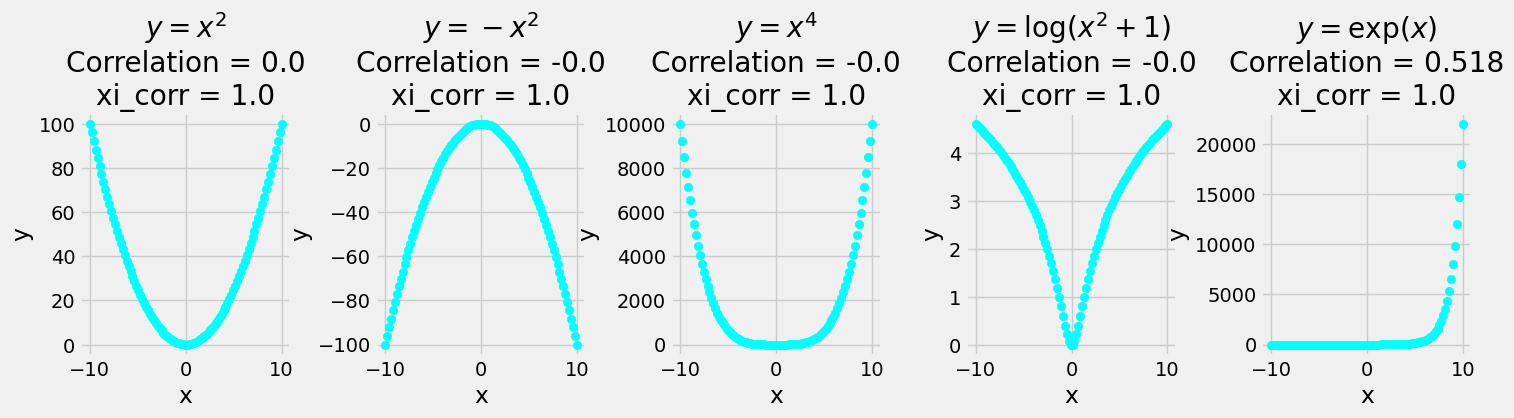

In [93]:
# Plot the data
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(16, 3))
title = ['$y=x^2$','$y=-x^2$','$y=x^4$','$y=\log(x^2+1)$','$y=\exp(x)$']
for i in [0,1,2,3,4]:
    xi = np.round(xicor(x_nonlinear[0,],x_nonlinear[1+i,],3))
    co = np.round(rho_nonlinear[0,i+1],3)
    ax[i].scatter(x_nonlinear[0,],x_nonlinear[1+i,],color='cyan')
    ax[i].title.set_text(f'{title[i]}' + '\n' + 
                         'Correlation = ' + f"{co}" + '\n' 
                         'xi_corr = ' + f"{xi}" )
    ax[i].set(xlabel='x',ylabel='y')
fig.subplots_adjust(wspace=.4)    
plt.show()

### 2 Noise

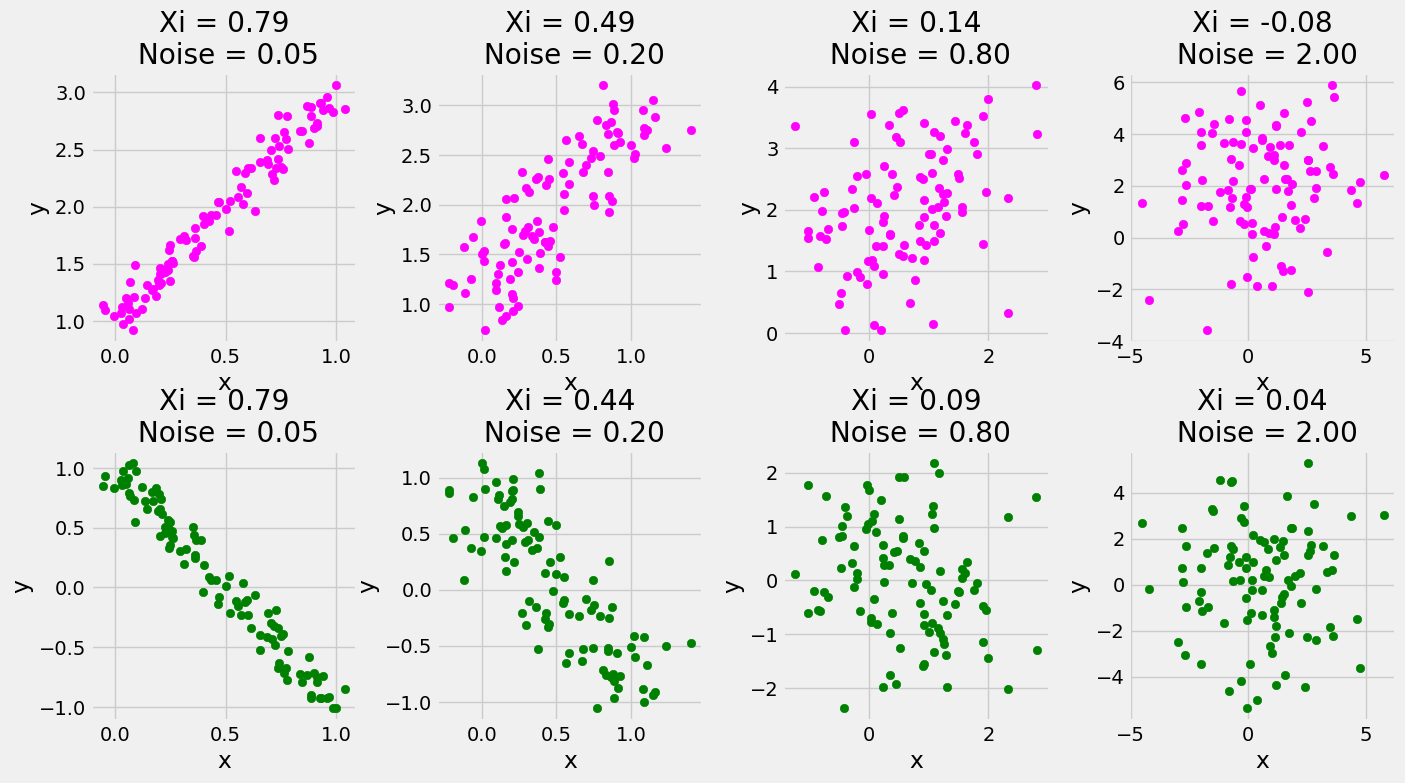

In [281]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))

for noise, i in zip([0.05,0.2,0.8,2],[0,1,2,3]):
    # Add noise
    x_with_noise = x+rand.normal(0,noise,x.shape)
    
    # Compute correlation
    rho_noise = xicor_matrix(x_with_noise)
    
    # Plot column wise. Positive correlation in row 0 and negative in row 1
    ax[0,i].scatter(x_with_noise[0,],x_with_noise[1,],color='magenta')
    ax[1,i].scatter(x_with_noise[0,],x_with_noise[2,],color='green')
    ax[0,i].title.set_text('Xi = ' + "{:.2f}".format(rho_noise[0,1])
                        + '\n Noise = ' + "{:.2f}".format(noise) )
    ax[1,i].title.set_text('Xi = ' + "{:.2f}".format(rho_noise[0,2])
                        + '\n Noise = ' + "{:.2f}".format(noise))
    ax[0,i].set(xlabel='x',ylabel='y')    
    ax[1,i].set(xlabel='x',ylabel='y')
    
fig.subplots_adjust(wspace=0.3,hspace=0.4)    
plt.show()

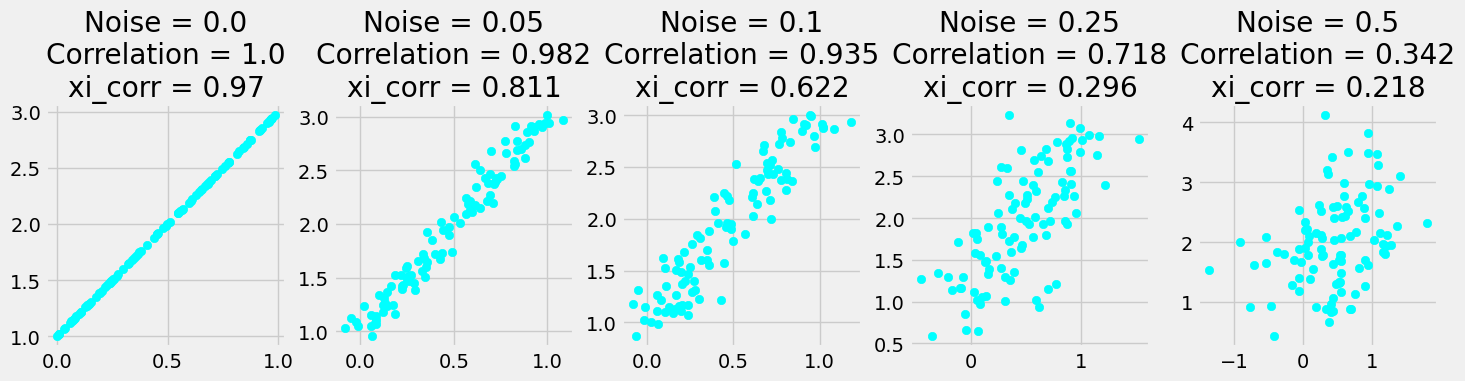

In [278]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(16, 3))

for noise, i in zip([0.00,0.05,0.1,0.25,0.5],[0,1,2,3,4]):
    # Add noise
    x_with_noise = x+rand.normal(0,noise,x.shape)
    
    # Compute correlation
    rho_noise = np.corrcoef(x_with_noise)
    x_ = x_with_noise[0,]
    y_ = x_with_noise[1,]
    xi = np.round(xicor(x_,y_),3)
    co = np.round(np.corrcoef(x_, y_)[0][1],3)
    ratio = np.round(xi/co*100,1)
    ax[i].scatter(x_,y_,color='cyan')
    ax[i].title.set_text(f'Noise = {noise}' + '\n' + 
                          'Correlation = ' + f"{co}" + '\n' 
                          'xi_corr = ' + f"{xi}" )
    # ax[i].set(xlabel='x',ylabel='y')
    # print(f'{noise}' + '\n' + 
    #                       'Correlation = ' + f"{co}" + '\n' 
    #                       'xi_corr = ' + f"{xi}" )



### Nonlinear with noise (70%)

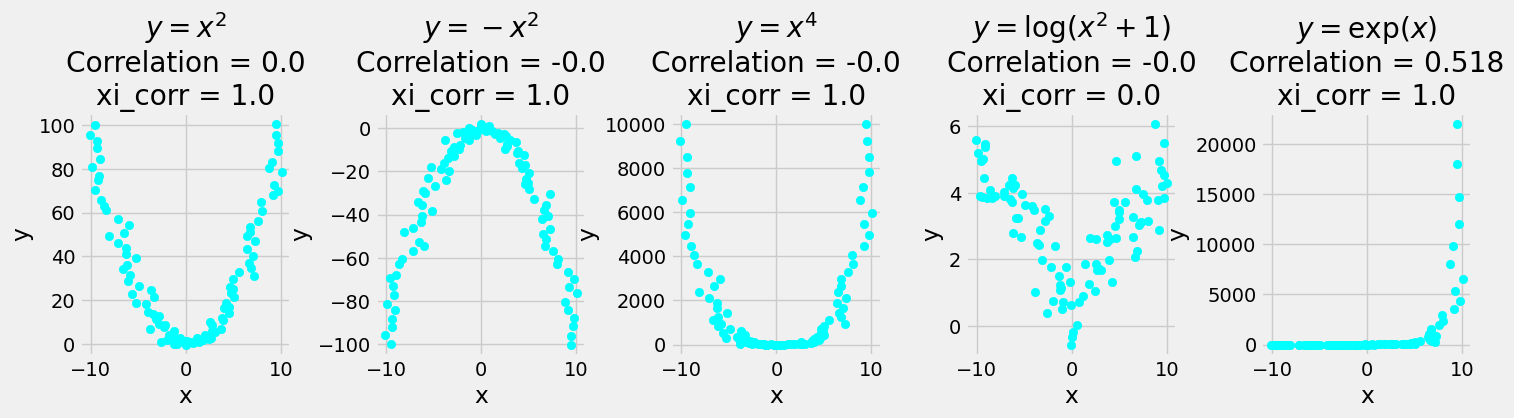

In [211]:
# Plot the data
x_nonlinear_with_noise = x_nonlinear + rand.normal(0,0.70,x_nonlinear.shape)
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(16, 3))
title = ['$y=x^2$','$y=-x^2$','$y=x^4$','$y=\log(x^2+1)$','$y=\exp(x)$']
for i in [0,1,2,3,4]:
    xi = np.round(xicor(x_nonlinear_with_noise[0,],x_nonlinear_with_noise[1+i,],3))
    co = np.round(rho_nonlinear[0,i+1],3)
    ax[i].scatter(x_nonlinear_with_noise[0,],x_nonlinear_with_noise[1+i,],color='cyan')
    ax[i].title.set_text(f'{title[i]}' + '\n' + 
                         'Correlation = ' + f"{co}" + '\n' 
                         'xi_corr = ' + f"{xi}" )
    ax[i].set(xlabel='x',ylabel='y')
fig.subplots_adjust(wspace=.4)    

plt.show()

## My Takeaway

 - it is quite interesting how resilient Xi happens to be to detect a relationship in the presence of very noisy non-linear data.

This is not the case when exploring noise in a linear relationship. Since:

 -  Little noise in linearity hides the underlying functional relationship much faster than it does under non-linear circumstances.

 
 -  Xi is almost binary: it detects clearly a functional relationship (xi=1) when noise is < 75%... but then it suddenly drops to zero. 


In [245]:
x_with_noise.shape

(4, 100)

In [247]:
rho_noise =xicor_matrix(x_with_noise)

TypeError: 'numpy.float64' object is not callable

TypeError: 'numpy.float64' object is not callable

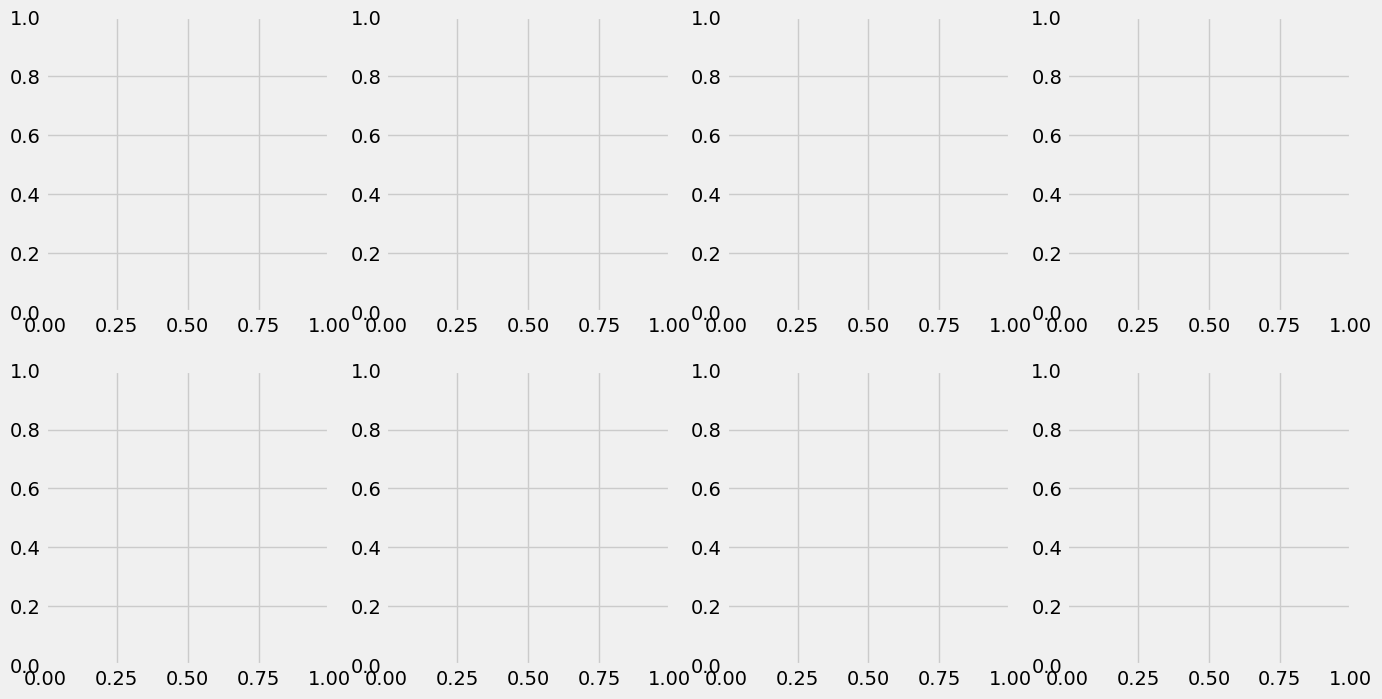

In [241]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))

for noise, i in zip([0.05,0.2,0.8,2],[0,1,2,3]):
    # Add noise
    x_with_noise = x+rand.normal(0,noise,x.shape)
    
    # Compute correlation
    rho_noise =xicor_matrix(x_with_noise)
    
    # Plot column wise. Positive correlation in row 0 and negative in row 1
    ax[0,i].scatter(x_with_noise[0,],x_with_noise[1,],color='magenta')
    ax[1,i].scatter(x_with_noise[0,],x_with_noise[2,],color='green')
    ax[0,i].title.set_text('Mutual Info = ' + "{:.2f}".format(rho_noise[0,1])
                        + '\n Noise = ' + "{:.2f}".format(noise) )
    ax[1,i].title.set_text('Mutual Info  = ' + "{:.2f}".format(rho_noise[0,2])
                        + '\n Noise = ' + "{:.2f}".format(noise))
    ax[0,i].set(xlabel='x',ylabel='y')    
    ax[1,i].set(xlabel='x',ylabel='y')
    
fig.subplots_adjust(wspace=0.3,hspace=0.4)    
plt.show()

# Mutual Information

In [236]:
mutual_info_matrix(pd.DataFrame(x_with_noise.T))

,0,1,2,3
0,1.000000,0.589484,0.667316,0.037116
1,0.589484,1.000000,0.665250,0.026378
2,0.667316,0.665250,1.000000,0.030520
3,0.037116,0.026378,0.030520,1.000000


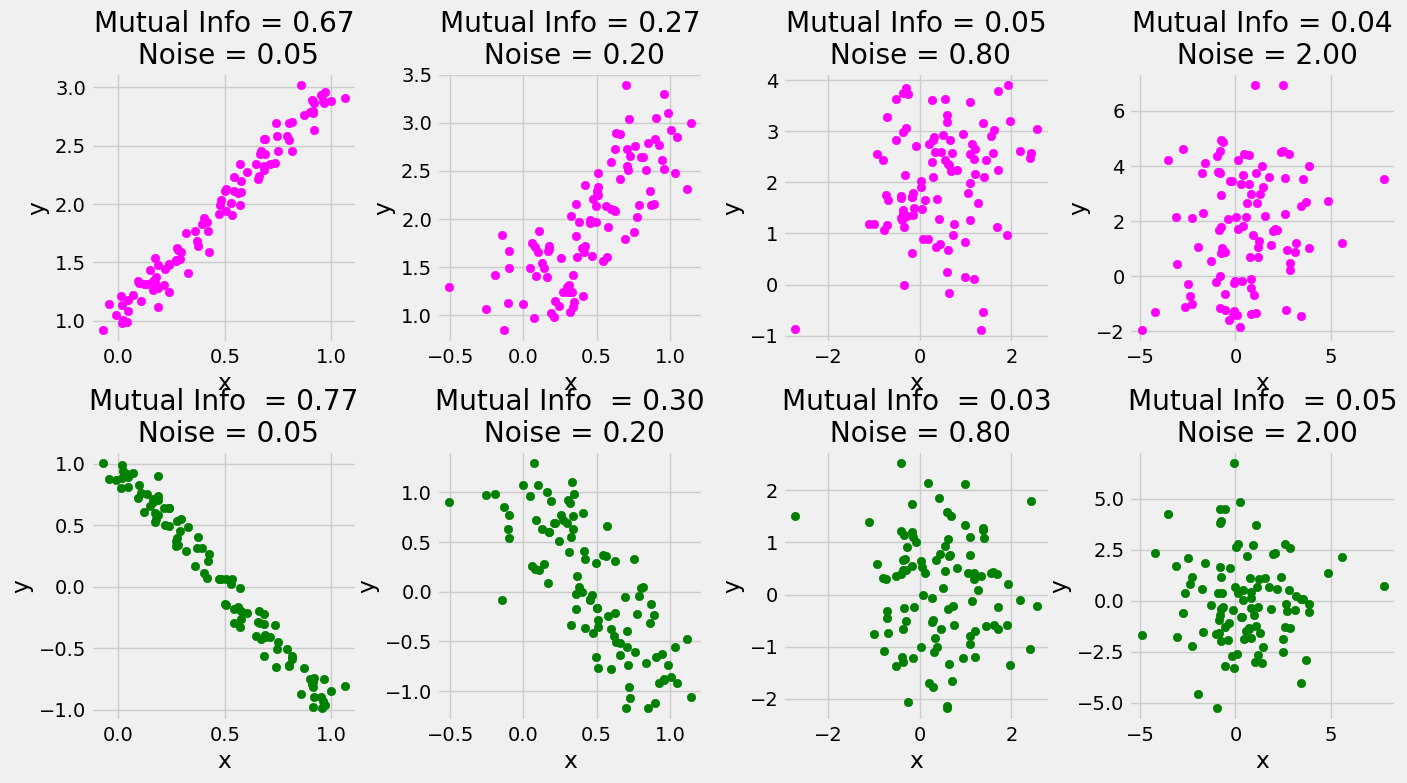

In [239]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))

for noise, i in zip([0.05,0.2,0.8,2],[0,1,2,3]):
    # Add noise
    x_with_noise = x+rand.normal(0,noise,x.shape)
    
    # Compute correlation
    rho_noise =mutual_info_matrix(pd.DataFrame(x_with_noise.T)).to_numpy()
    
    # Plot column wise. Positive correlation in row 0 and negative in row 1
    ax[0,i].scatter(x_with_noise[0,],x_with_noise[1,],color='magenta')
    ax[1,i].scatter(x_with_noise[0,],x_with_noise[2,],color='green')
    ax[0,i].title.set_text('Mutual Info = ' + "{:.2f}".format(rho_noise[0,1])
                        + '\n Noise = ' + "{:.2f}".format(noise) )
    ax[1,i].title.set_text('Mutual Info  = ' + "{:.2f}".format(rho_noise[0,2])
                        + '\n Noise = ' + "{:.2f}".format(noise))
    ax[0,i].set(xlabel='x',ylabel='y')    
    ax[1,i].set(xlabel='x',ylabel='y')
    
fig.subplots_adjust(wspace=0.3,hspace=0.4)    
plt.show()

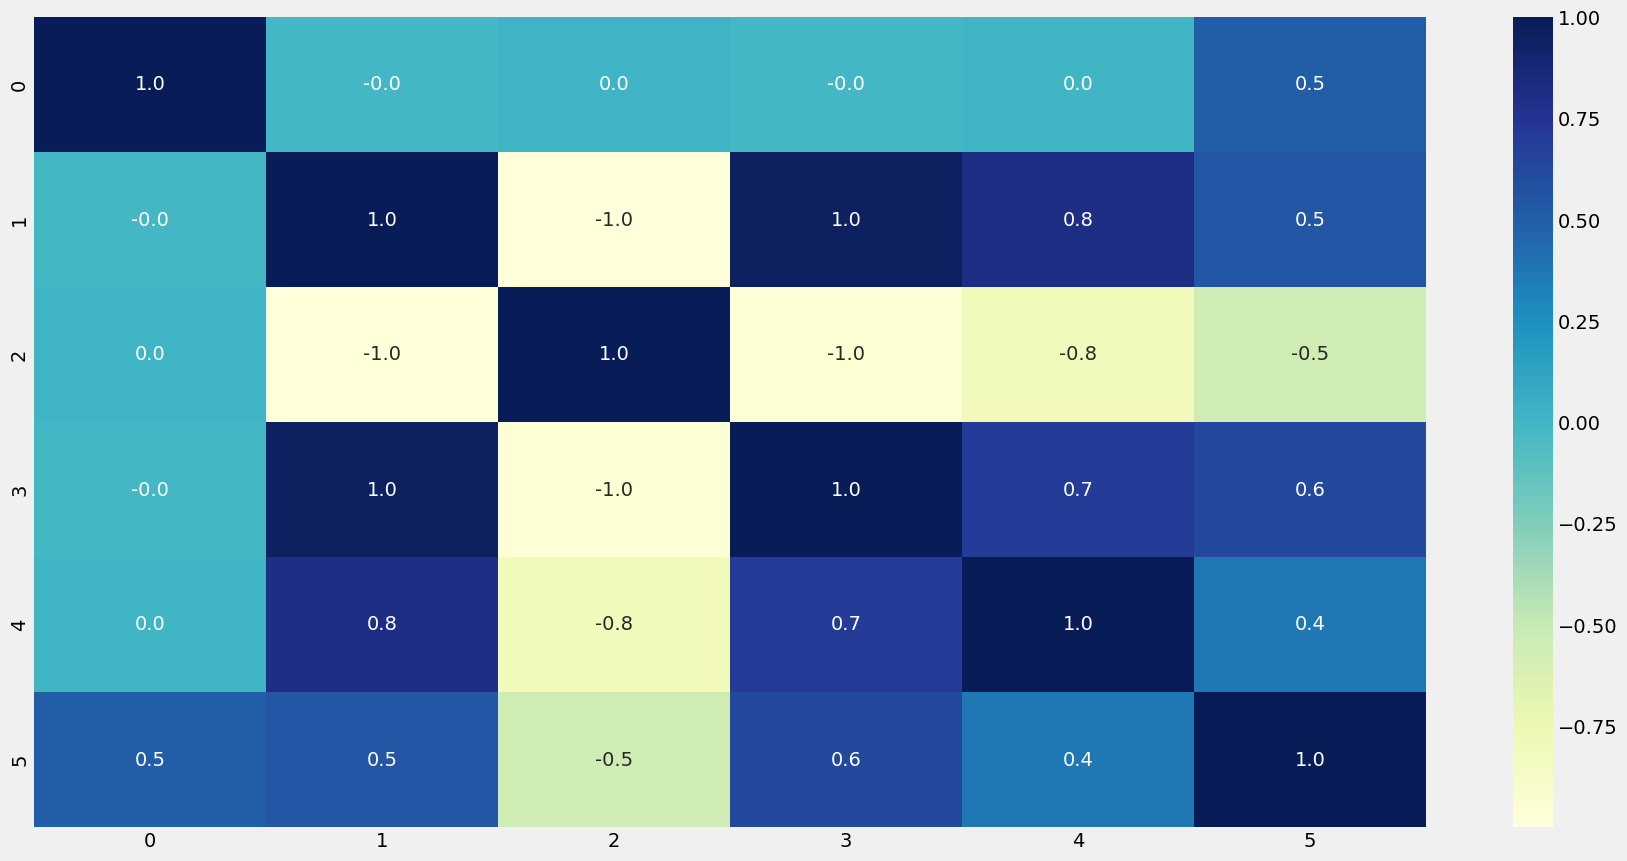

In [210]:
mc_df = pd.DataFrame(np.corrcoef(x_nonlinear_with_noise))

sns.heatmap(mc_df, annot=True, cmap="YlGnBu", fmt=".1f");

In [204]:
import pandas as pd
import seaborn as sns
%matplotlib inline
df = pd.DataFrame(x_nonlinear_with_noise.T)

mi_df = (mutual_info_matrix(df))

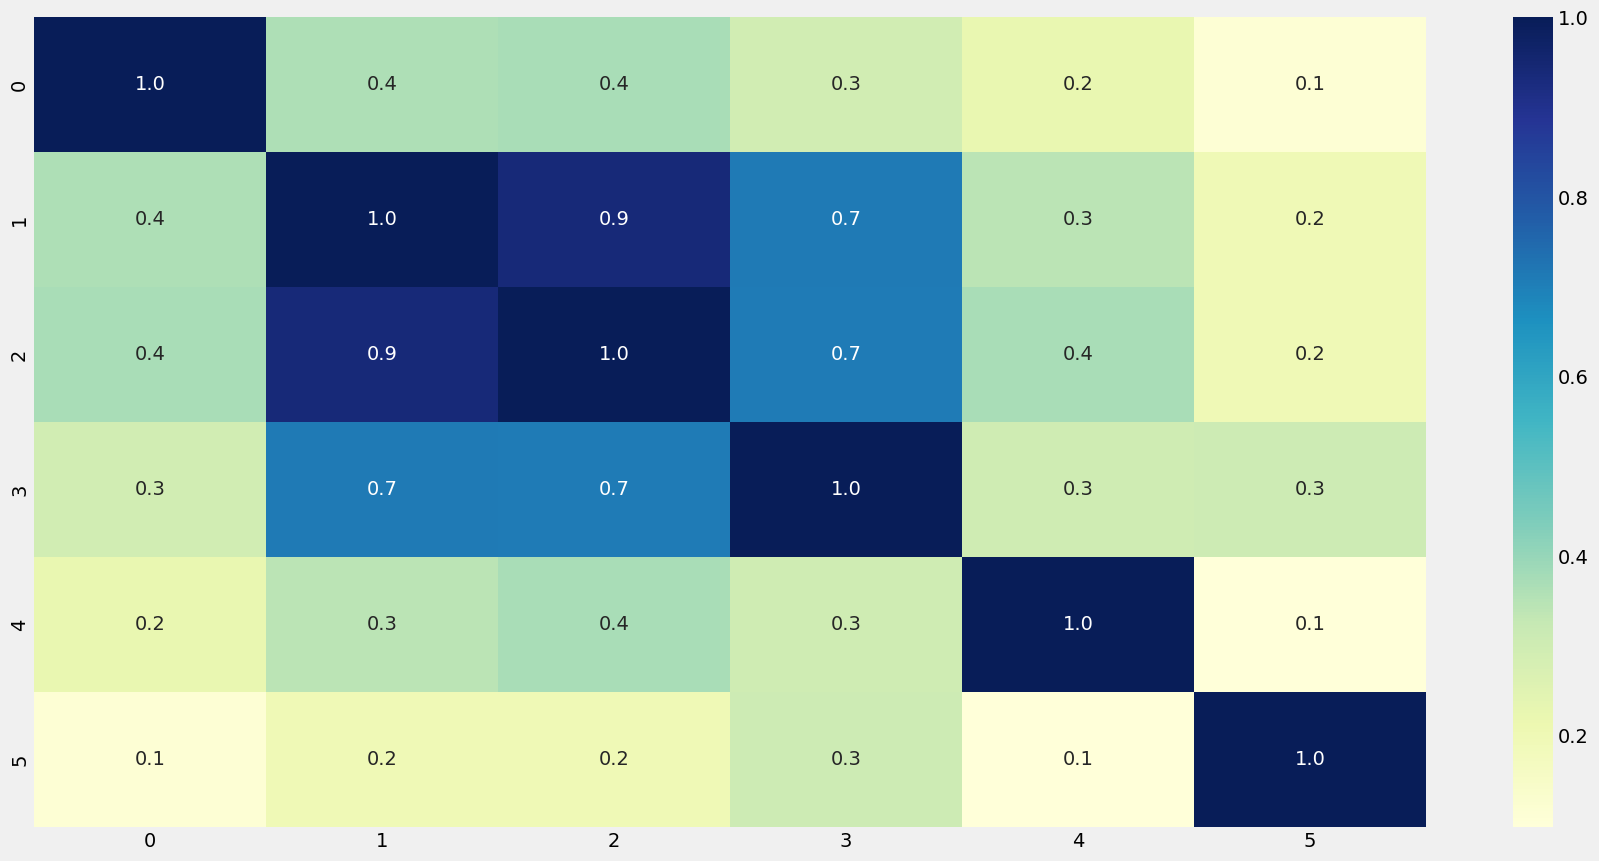

In [205]:
sns.heatmap(mi_df, annot=True, cmap="YlGnBu", fmt=".1f");

In [256]:
pd.DataFrame(x_nonlinear_with_noise.T)

,0,1,2,3,4,5
0,-9.514177,100.007543,-100.120815,10000.088644,4.955584,0.087250
1,-10.105509,95.670097,-96.077724,9215.724475,5.567936,-0.288613
2,-9.407569,92.742846,-92.278681,8478.937166,3.876967,0.839713
3,-9.388787,89.574439,-88.230631,7787.869851,4.995408,0.037067
4,-9.080989,84.352827,-84.248577,7139.247984,5.357460,-0.759478
...,...,...,...,...,...,...
95,9.102360,83.090671,-84.049540,7139.037147,3.766081,9817.861763
96,9.716862,88.180094,-87.833778,7788.460189,3.834362,12015.200065
97,9.715048,91.684392,-91.788918,8479.996281,5.476601,14706.463574
98,9.489790,95.636212,-96.184901,9216.165086,4.198331,17996.730621


In [253]:
xicor_df = xicor_matrix(x_nonlinear_with_noise)

TypeError: 'numpy.float64' object is not callable

In [217]:
len(xicor_df)

6

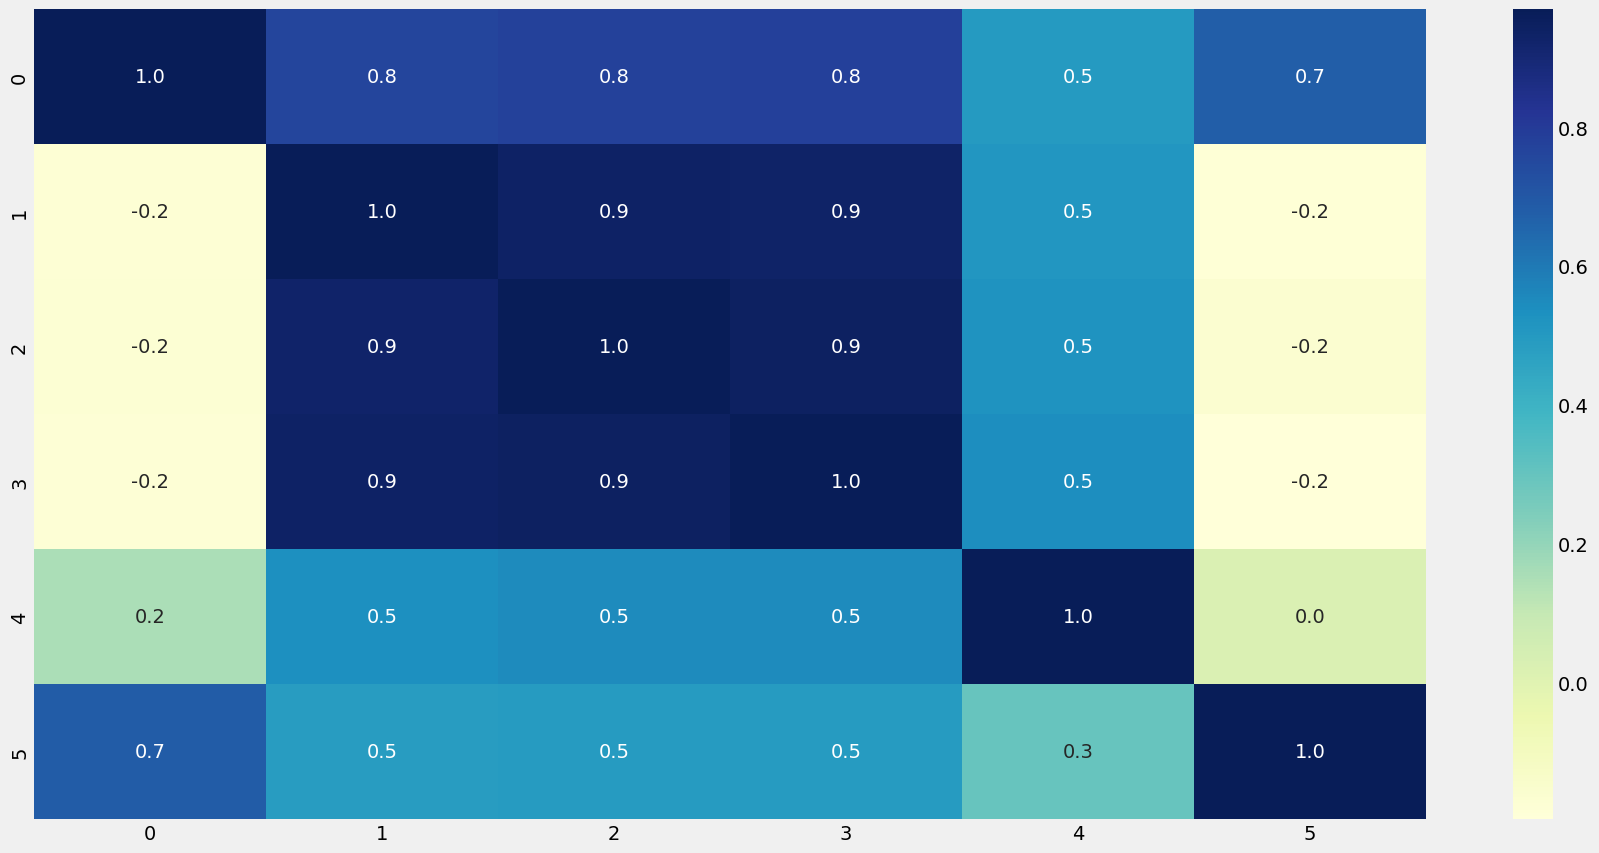

In [224]:
sns.heatmap(xicor_df, annot=True, cmap="YlGnBu", fmt=".1f");